In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

  Activating project at `~/projects/EccentricBurstTimings`


In [2]:
using EccentricBurstTiming, CairoMakie, CSV, DataFrames, QuadGK
using Unitful, UnitfulAstro
defaulttheme = Theme(Axis = (xgridvisible=false, ygridvisible=false,
                            yminorticks=IntervalsBetween(4),
                            xminorticks=IntervalsBetween(4),
                            yminorticksvisible=true,
                            xminorticksvisible=true,
                            titlefont = :regular,
                            xminorticksize=3,
                            yminorticksize=3,
                            ylabelsize=20,
                            xlabelsize=20
                            ),
                    Legend = (framevisible=false,),
                    size=(800, 600))
set_theme!(defaulttheme)
update_theme!(theme_latexfonts())

const EBT = EccentricBurstTiming


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


EccentricBurstTiming

In [3]:
# const G = EccentricBurstTiming.Constants.G
# const G_solar = 3.9413556368747037e-7 # R⊙^3 s^-2 M⊙^-1

function get_unperturbed_model(;args...)
    args = copy(args)
    args[:m3] = 0.0

    return  BurstTimingModel(;args...)
end

function get_perturbed_model(;args...)
    args = copy(args)

    return  BurstTimingModel(;args...)
end

function get_models(;args...)

    m = get_unperturbed_model(;args...)
    m_p =  get_perturbed_model(;args...)
    
    return m, m_p
end

function do_evolution(N; args...)

    model_perturbed = BurstTimingModel(;args...)
    up_args = copy(args)
    up_args[:m3] = 0.0
    model_unperturbed = BurstTimingModel(;up_args...)

    evolve!(model_perturbed, N)
    evolve!(model_unperturbed, N)

    return model_perturbed, model_unperturbed
end

function do_evolution_up(N; args...)

    model = BurstTimingModel(m3=0.0; args...)

    evolve!(model, N)

    return model
end

function do_evolution_pert(N; args...)

    model_perturbed = BurstTimingModel(;args...)

    evolve!(model_perturbed, N)

    return model_perturbed
end

function get_max_shift(model_unperturbed, model_perturbed, N)
    t_perturbed = get_t_array(model_perturbed, N)
    t_unperturbed = get_t_array(model_unperturbed, N)
    time_shift = line_up_burst_times(t_perturbed, t_unperturbed)
    t_unperturbed .+= time_shift
    
    N_perturbed = length(t_perturbed)
    N_unperturbed = length(t_unperturbed)
    if N_perturbed > N_unperturbed
        dt = maximum(abs.(t_perturbed[1:N_unperturbed] - t_unperturbed))
    elseif N_perturbed < N_unperturbed
        dt = maximum(abs.(t_perturbed - t_unperturbed[1:N_perturbed]))
    else
        dt = maximum(abs.(t_perturbed - t_unperturbed))
    end
    
    return dt
end

function decay_time_s(a0, e0, m1, m2)
    G³ = EccentricBurstTiming.Constants.G^3
    c⁵ = EccentricBurstTiming.Constants.c^5 #1.359886513235705e7^5 # EccentricBurstTiming.Constants.G_solar^5

    c0 = a0*(1 - e0^2)/(e0^(12/19))*(1 + 121/304*e0^2)^(-870/2299)
    β = 64/5*(G³*m1*m2*(m1 + m2))/c⁵
    integral(e) = (e^(29/19)*(1 + (121/304)*e^2)^(1181/2299))/sqrt(1 - e^2)^3

    int, err = quadgk(integral, 0, e0)

    T = 12/19*c0^4/β*int
    return T
end

decay_time_s (generic function with 1 method)

## Overview of parameters
### Inner binary parameter

- $m_{12}$: inner binary total mass
    - this is set to 1 in the equations, but given when instantiating the model to scale everything else
- $a_0$: inner semi-major axis
- $e_0$: inner eccentricity
- $\omega$: inner argument of pericentre
- $\Omega$: inner longitude of ascending node
- $i$: inclination

### Outer binary parameters
- $m_3$: perturber mass
- $R_3$: outer semi-major axis
- $e_3$: outer eccentricity
- $\omega_3$: outer argument of pericentre
- $\Omega_3$: outer longitude of ascending node (just observational parameter?)
- $\iota_3$: outer inclination (observational)

## The system

In [4]:
const au_to_Rsun = 214.4772339784946

214.4772339784946

In [5]:
begin
    extreme_examples = CSV.File(joinpath(@__DIR__, "..", "data", "processed", "extreme_examples.csv"))
    example = extreme_examples[2]

    # set params
    e0 = example.e_in
    a0 = example.a_in
    m1, m2 = example.m1, example.m2
    m12 = m1 + m2
    eta = (m1*m2)/m12/m12
    i0 = example.incl
    
    R3 = example.a_out
    m3 = example.m3
    e3 = example.e_out

    println(a0, " ", R3, " ", m1, " ", m2, " ", m3)
    
    # free(?) params
    w0 = 0.0
    W0 = 0.0
    w3 = 0.0
    W3 = 0.0
    V3 = 0.0
    
    
    N = 50
    params = [:V3, :w0, :W0, :w3, :W3]
    param_labels = [L"$V_{3,0}$ [rad]", L"$\omega_0$ [rad]", L"$\Omega_0$ [rad]", L"$\omega_{3,0}$ [rad]", L"$\Omega_{3, 0}$ [rad]"]
    V3_range = range(0, stop=2π, length=15)
    ang_range = range(0, stop=π, length=15)
    param_values = [V3_range, ang_range, ang_range, ang_range, ang_range]
    all_params = Dict(:a0 => a0, :e0 => e0, :m12 => m12, :i0 => i0, :w0 => w0, :W0 => W0,
                      :w3 => w3, :e3 => e3, :R3 => R3, :m3 => m3, :V3 => V3, :eta => eta)
end

7.05396311596 657.061190187 53.3216769873 53.3216769873 42.3328244064


Dict{Symbol, Float64} with 12 entries:
  :w3  => 0.0
  :W0  => 0.0
  :i0  => 0.87371
  :e3  => 0.698111
  :m12 => 106.643
  :R3  => 657.061
  :w0  => 0.0
  :eta => 0.25
  :V3  => 0.0
  :a0  => 7.05396
  :m3  => 42.3328
  :e0  => 0.829625

In [6]:
let (m, m_p) = get_models(;all_params...)
    println(EccentricBurstTiming.peak_f_GW(m_p))
    EBT.evolve_to_fGW!(m_p, 0.5, max_bursts=100_000)
    println(EccentricBurstTiming.peak_f_GW(m_p))
end

0.0013058676631503656
0.5034741604445462


[5.239761691825391, 5.13837391319274, 5.036023312369578, 4.9331194712024375, 4.830059342025286, 4.72722025070797, 4.624954187507621, 4.523583487343386, 4.423397901614641, 4.324652981436906, 4.227569631603531, 4.132334656595257, 4.039102102717821, 3.947995200357487, 3.8591087230283376, 3.7725116009235937, 3.6882496521735018, 3.606348321810335, 3.526815344268596, 3.449643268632344, 3.3748118059781325, 3.302289974756382, 3.232038033300267, 3.1640091985190226, 3.0981511570675435, 3.0344073802252587, 2.9727182568308286, 2.9130220603068633, 2.855255766438983, 2.7993557384305445, 2.7452582950959727, 2.6929001770501775, 2.6422189245601873, 2.5931531794380103, 2.5456429220552588, 2.499629653296849, 2.45505653007903, 2.4118684619517556, 2.3700121753011905, 2.3294362507653013, 2.290091138672014, 2.251929156602005, 2.214904472558166, 2.1789730766849646, 2.144092744015446, 2.110222990320858, 2.0773250227953266, 2.0453616870126425, 2.014297411342937, 1.9840981498041224, 1.9547313241437192, 1.9261657

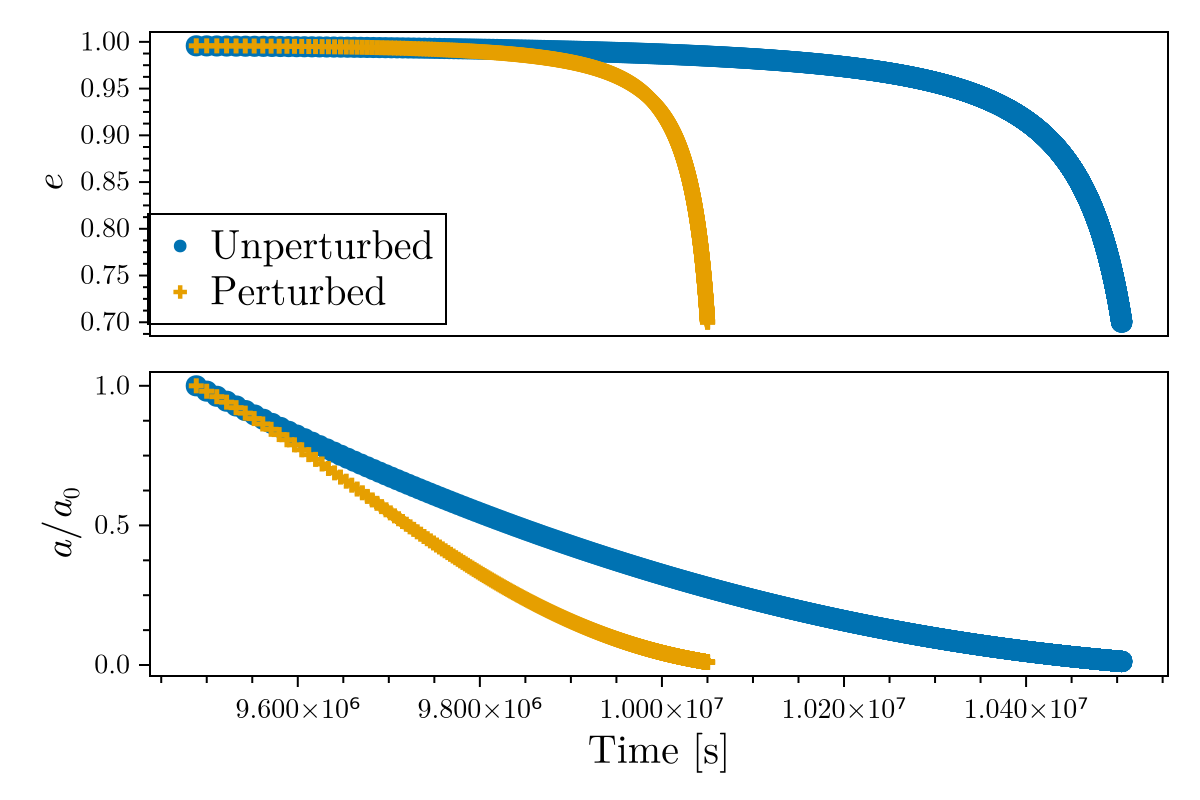

In [45]:
let
    N = 10000
    
    fig = Figure(size=(600, 400))
    cs = Makie.wong_colors()

    ax_e = Axis(fig[1, 1], ylabel=L"e", yticks=LinearTicks(7))
    ax_p = Axis(fig[2, 1], xlabel="Time [s]", ylabel=L"a/a_0")

    hidexdecorations!(ax_e)
    linkxaxes!(ax_e, ax_p)

    m, m_p = get_models(;all_params...)#do_evolution(N; all_params...)

    # EBT.evolve_to_fGW!(m, 0.01, max_bursts=100_000)
    EBT.evolve_to_fGW!(m_p, 0.5, max_bursts=100_000)
    m = let
        params = copy(all_params)
        params[:m3] = 0.0
        params[:a0] = get_a(m_p, 1)/EBT.Constants.Rsun_to_m
        params[:e0] = get_e(m_p, 1)
        params[:t0] = get_t(m_p, 1)
        get_unperturbed_model(;params...)
    end


    evolve!(m, N)
    evolve!(m_p, N)
    println(get_a_array(m_p, N) /EBT.Constants.Rsun_to_m)
    println(EBT.peak_f_GW(m_p, length(m_p.t)))

    e = get_e_array(m, N)
    a = get_a_array(m, N) 
    t = get_t_array(m, N)

    e_p = get_e_array(m_p, N)
    a_p = get_a_array(m_p, N) 
    t_p = get_t_array(m_p, N)

    time_shift = line_up_burst_times(t_p, t)
    # t .+= time_shift
    # @show time_shift

    sc = scatter!(ax_e, t, e, color=cs[1], markersize=15)
    sc2 = scatter!(ax_p, t, a ./ a[1], color=cs[1], markersize=15)

    sc = scatter!(ax_e, t_p, e_p, color=cs[2], markersize=10, marker=:+)
    sc2 = scatter!(ax_p, t_p, a_p ./ a_p[1], color=cs[2], markersize=10, marker=:+)
    axislegend(ax_e, [MarkerElement(color=cs[1], marker=:circle), MarkerElement(color=cs[2], marker=:+)], 
                     ["Unperturbed", "Perturbed"], position=:lb, labelsize=20, framevisible=true)
    # Makie.save(joinpath(@__DIR__, "..", "figures", "example_system.png"), fig)
    fig
end

Look at frequencies 1e-4 and up

## Effect of new parameters on change in eccentricity

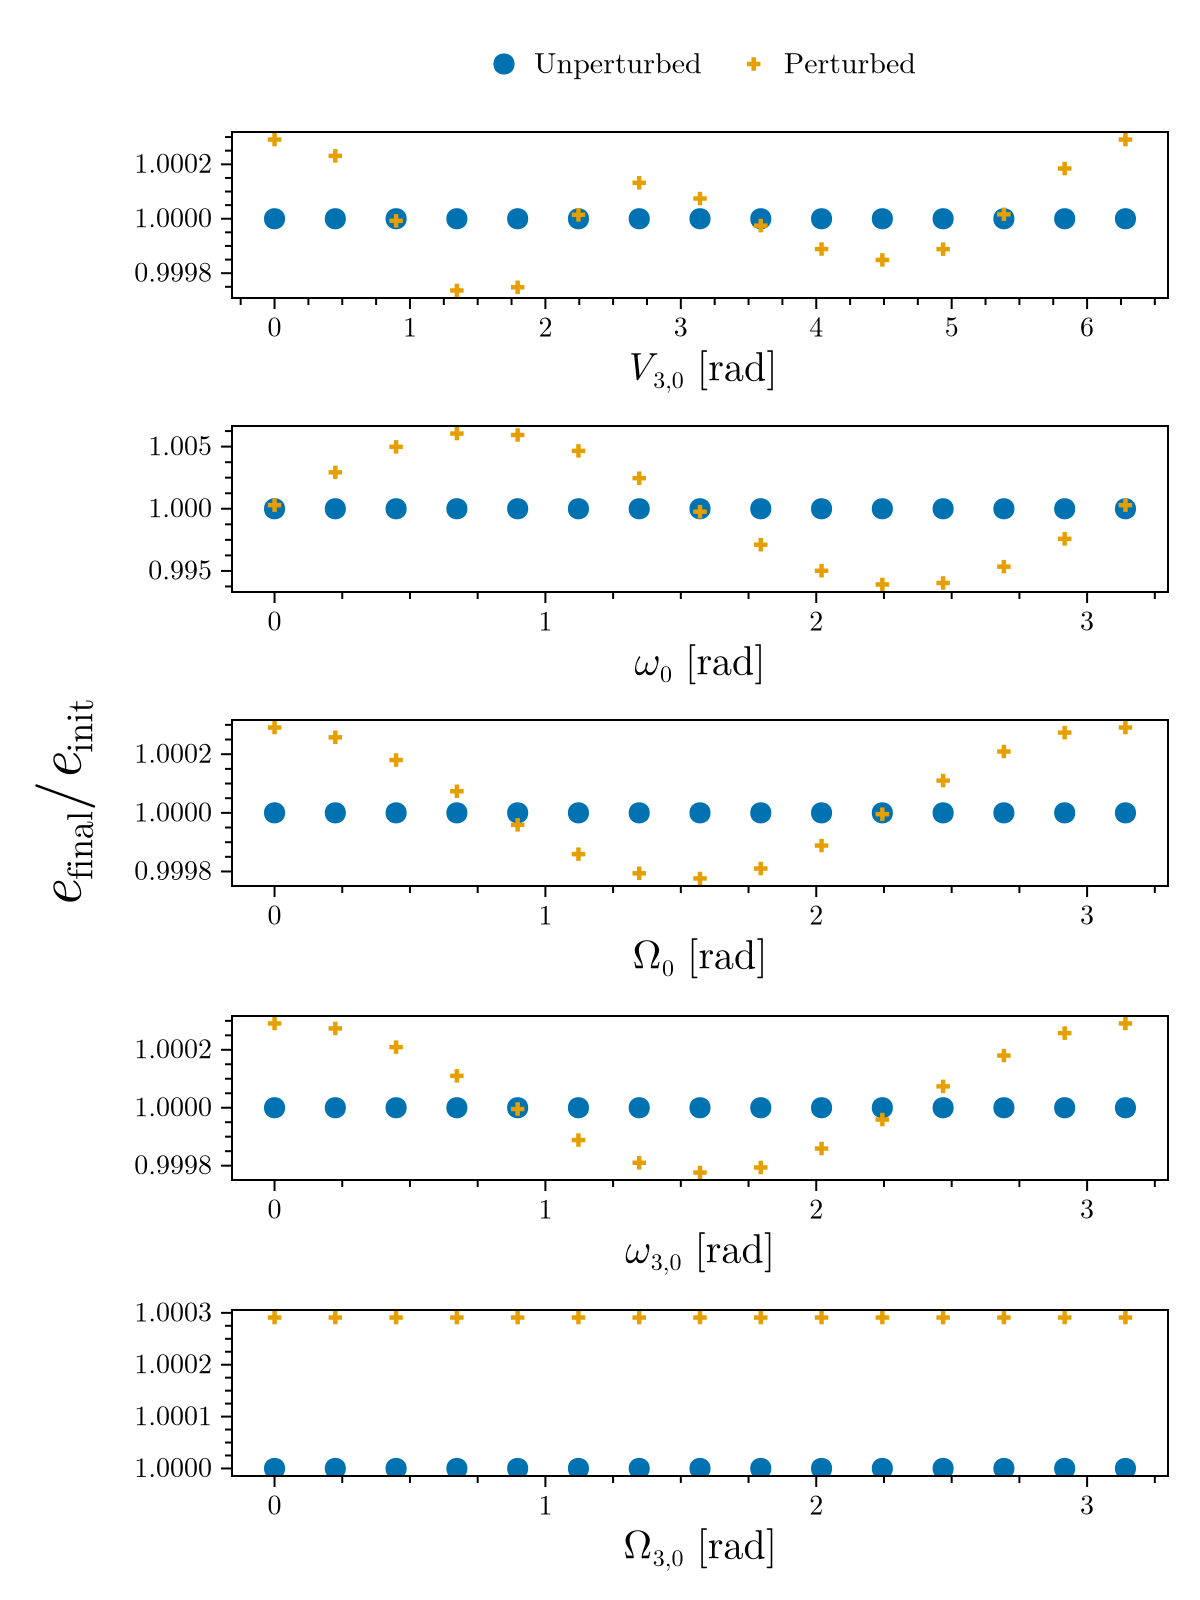

In [18]:
let

    fig = Figure(size=(600, 800))
    Label(fig[1:5,0], L"e_\text{final}/e_\text{init}", rotation=π/2, fontsize=30)
    axes = [Axis(fig[i, 1], xlabel=param_labels[i], xlabelsize=20, yscale=identity) for i = 1:5]

    cs = Makie.wong_colors()

    for (i, (param, vals)) in enumerate(zip(params, param_values))
        for v in vals
            my_params = copy(all_params)
            my_params[param] = v
            m_p, m = do_evolution(N; my_params...)

            e = get_e_array(m, N)
            e_p = get_e_array(m_p, N)

            y1 = e[end] / e[1]
            y2 = e_p[end] / e_p[1]
            scatter!(axes[i], v, y1, color=cs[1], markersize=15)
            scatter!(axes[i], v, y2, color=cs[2], marker=:+)
        end
    end
    Legend(fig[0,1], [MarkerElement(color=cs[1], markersize=15, marker=:circle), 
                        MarkerElement(color=cs[2], marker=:+)],
                       ["Unperturbed", "Perturbed"], orientation=:horizontal, labelsize=15)
    # Makie.save(joinpath(@__DIR__, "..", "figures", "delta_e_vs_params.png"), fig)
    fig
end

## Effect of new parameters on change in sma

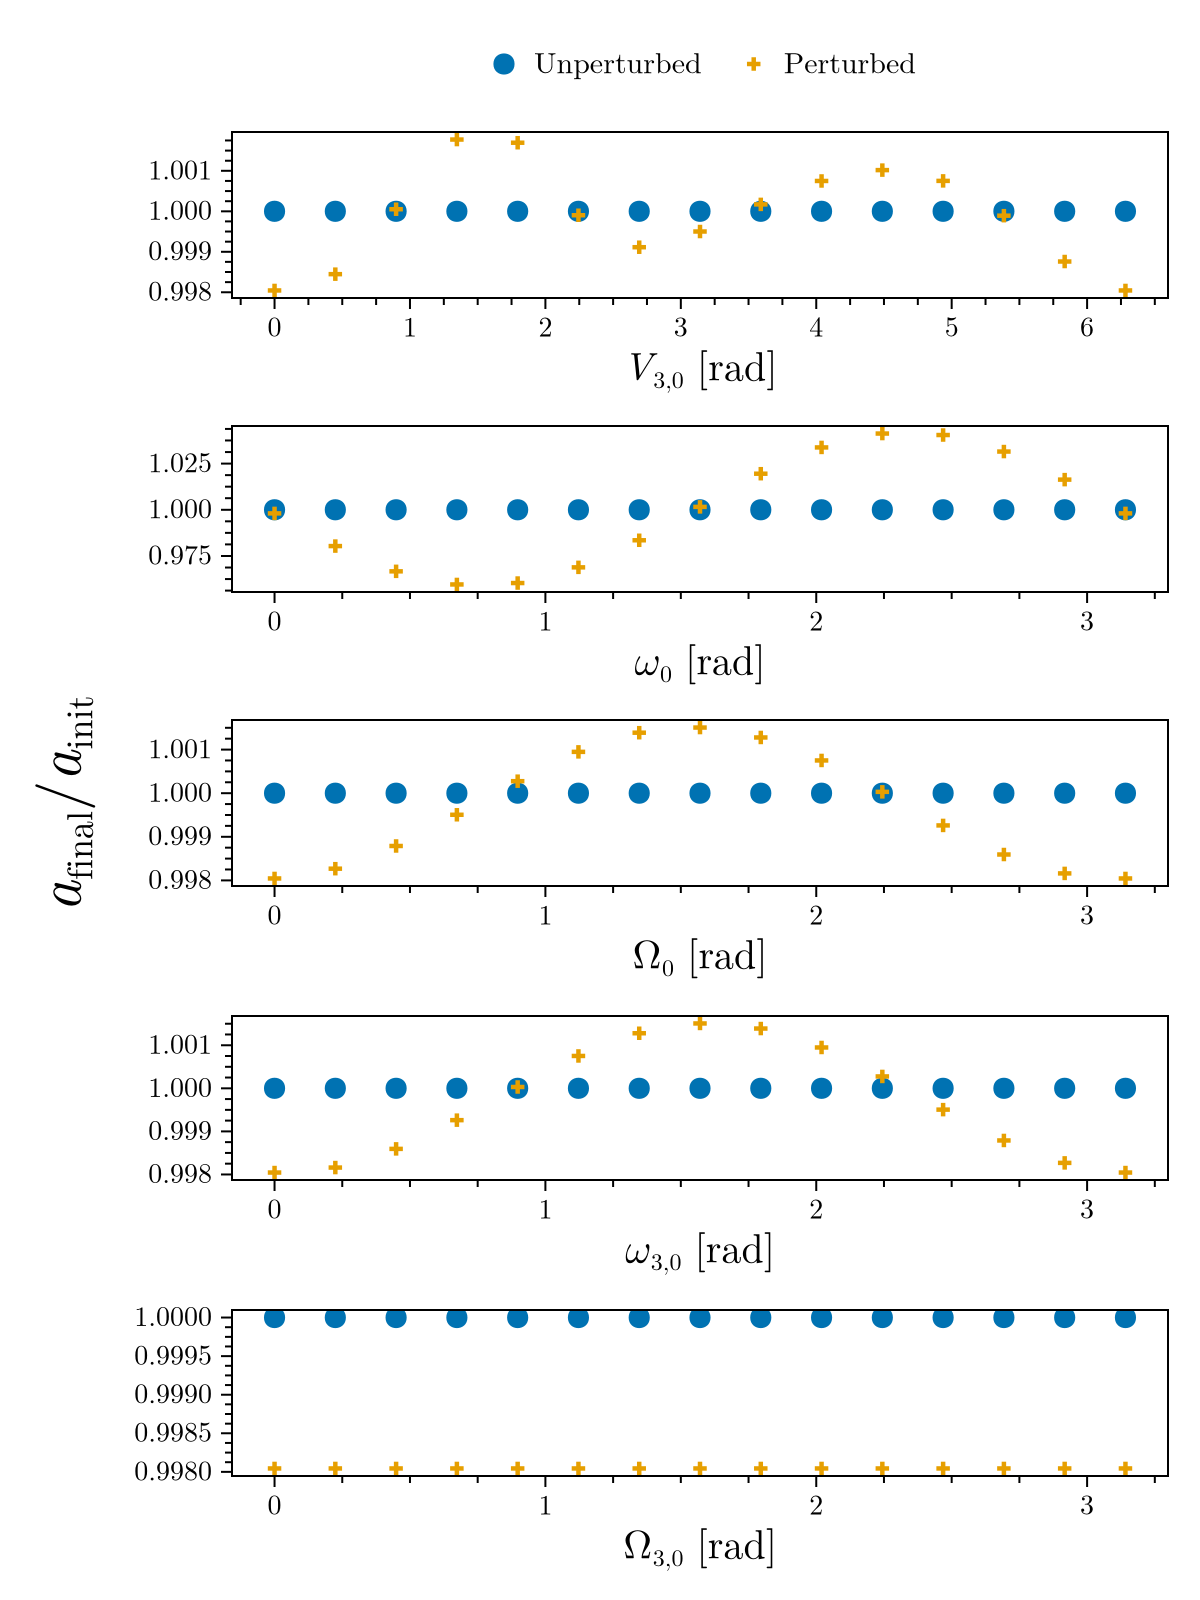

In [21]:
let

    fig = Figure(size=(600, 800))
    Label(fig[1:5,0], L"a_\text{final}/a_\text{init}", rotation=π/2, fontsize=30)
    axes = [Axis(fig[i, 1], xlabel=param_labels[i], xlabelsize=20, yscale=identity) for i = 1:5]

    cs = Makie.wong_colors()

    for (i, (param, vals)) in enumerate(zip(params, param_values))

        for v in vals
            my_params = copy(all_params)
            my_params[param] = v
            m_p, m = do_evolution(N; my_params...)

            # p = get_p_array(m, N)
            # p_p = get_p_array(m_p, N)
            a = get_p_array(m, N) .* (1 .- get_e_array(m, N) .^ 2)
            a_p = get_p_array(m_p, N) .* (1 .- get_e_array(m_p, N) .^ 2)

            y1 = a[end] / a[1]
            y2 = a_p[end] / a_p[1]
            scatter!(axes[i], v, y1, color=cs[1], markersize=15)
            scatter!(axes[i], v, y2, color=cs[2], marker=:+)
        end
    end

    Legend(fig[0,1], [MarkerElement(color=cs[1], markersize=15, marker=:circle), 
                        MarkerElement(color=cs[2], marker=:+)],
                       ["Unperturbed", "Perturbed"], orientation=:horizontal, labelsize=15)
    # Makie.save(joinpath(@__DIR__, "..", "figures", "delta_a_vs_params.png"), fig)
    fig
end

# Population

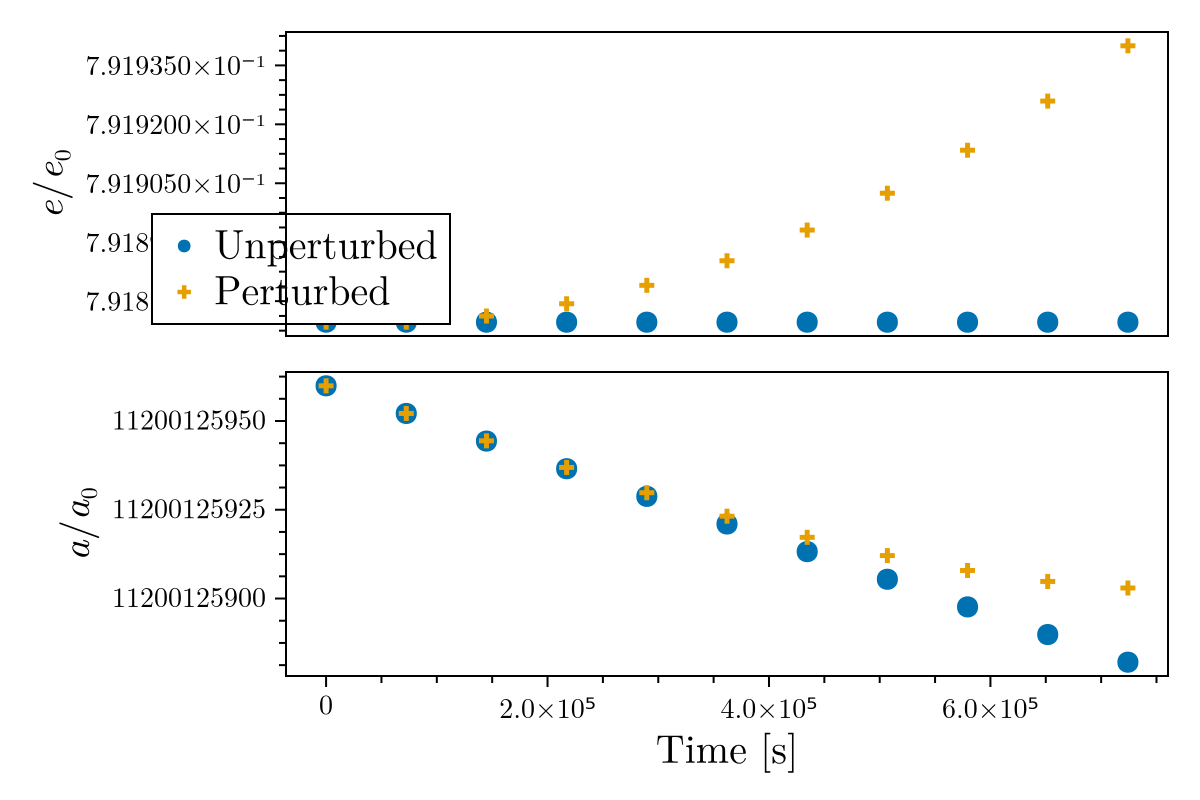

In [57]:
let filename = "../data/kummer2024/data_models/basic_high_density_Z0005.csv"
    df = CSV.File(filename)
    df = df[df.e_in .> 0.7, :]

    fig = Figure(size=(600, 400))
    cs = Makie.wong_colors()
    ax_e = Axis(fig[1, 1], ylabel=L"e/e_0", yticks=LinearTicks(7))
    ax_p = Axis(fig[2, 1], xlabel="Time [s]", ylabel=L"a/a_0")

    hidexdecorations!(ax_e)
    linkxaxes!(ax_e, ax_p)

    i = 1
    N_bursts = 10

    row = df[i,:][1]

    e0 = row.e_in
    a0 = row.a_in
    m1, m2 = row.m1, row.m2
    m12 = m1 + m2
    eta = (m1*m2)/m12/m12
    i0 = row.incl
    
    R3 = row.a_out
    m3 = row.m3
    e3 = row.e_out

    # println(a0, " ", R3, " ", m1, " ", m2, " ", m3)
    
    # free(?) params
    w0 = 0.0
    W0 = 0.0
    w3 = 0.0
    W3 = 0.0
    V3 = 0.0

    params = Dict(:a0 => a0, :e0 => e0, :m12 => m12, :i0 => i0, :w0 => w0, :W0 => W0,
                    :w3 => w3, :e3 => e3, :R3 => R3, :m3 => m3, :V3 => V3, :eta => eta)

    m_p = get_perturbed_model(;params...)

    # EBT.evolve_to_fGW!(m_p, 0.5, max_bursts=100_000)
    m = let
        bin_params = copy(params)
        bin_params[:m3] = 0.0
        bin_params[:a0] = get_a(m_p, 1)/EBT.Constants.Rsun_to_m
        bin_params[:e0] = get_e(m_p, 1)
        bin_params[:t0] = get_t(m_p, 1)
        get_unperturbed_model(;bin_params...)
    end

    evolve!(m, N_bursts)
    evolve!(m_p, N_bursts)

    e = get_e_array(m, N_bursts)
    a = get_a_array(m, N_bursts) 
    t = get_t_array(m, N_bursts)

    e_p = get_e_array(m_p, N_bursts)
    a_p = get_a_array(m_p, N_bursts) 
    t_p = get_t_array(m_p, N_bursts)

    time_shift = line_up_burst_times(t_p, t)
    # t .+= time_shift

    sc = scatter!(ax_e, t, e, color=cs[1], markersize=15)
    sc2 = scatter!(ax_p, t, a, color=cs[1], markersize=15)

    sc = scatter!(ax_e, t_p, e_p, color=cs[2], markersize=10, marker=:+)
    sc2 = scatter!(ax_p, t_p, a_p, color=cs[2], markersize=10, marker=:+)
    axislegend(ax_e, [MarkerElement(color=cs[1], marker=:circle), MarkerElement(color=cs[2], marker=:+)], 
                     ["Unperturbed", "Perturbed"], position=:lb, labelsize=20, framevisible=true)

    fig
end

0.9962926038906522 15.933827035204402
0.9956140560438399 13.455198051913953
0.9936081264714105 8.841881227892083
0.9907722487060074 6.993115274068313
0.9906638832153185 6.9742000696302044
0.996359353926123 16.07757934300355
0.9934959025693582 9.360504996047455
0.9967711625198962 15.736494989879969
0.9941852060821237 9.277120790371216


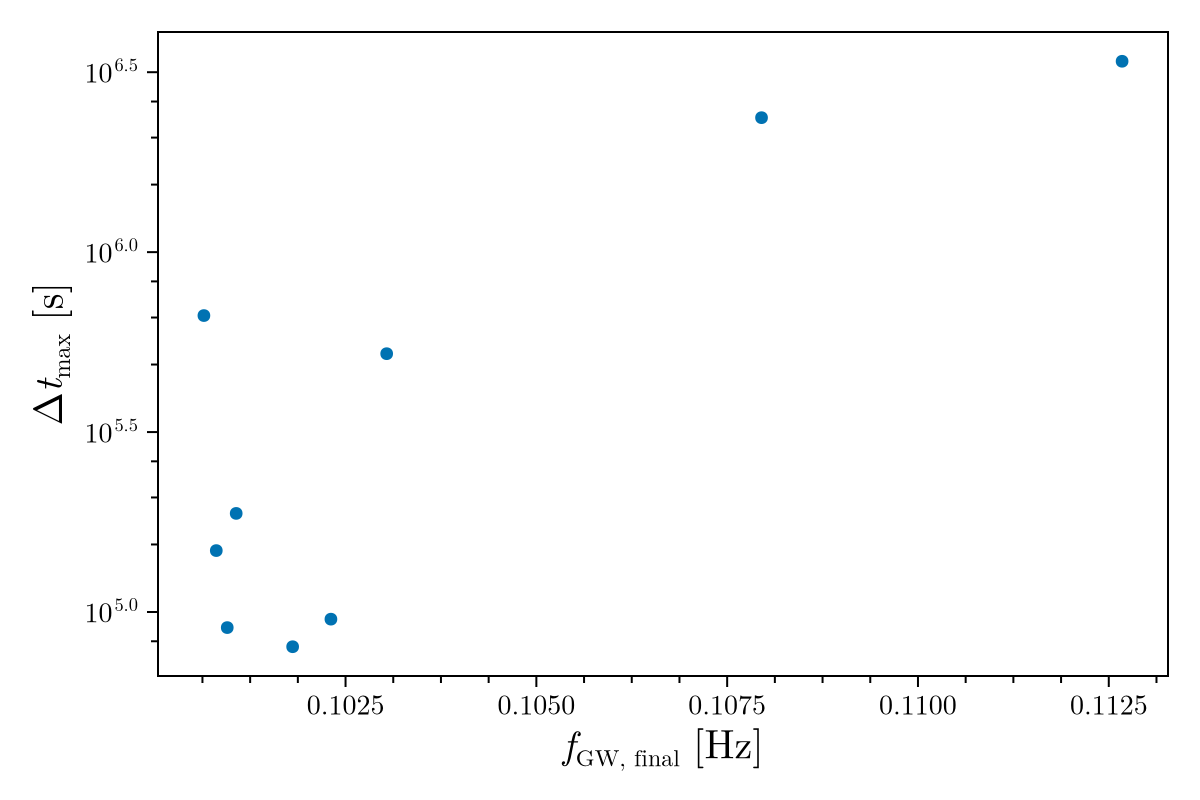

In [36]:
let filename = "../data/kummer2024/data_models/basic_high_density_Z0005.csv"
    df = CSV.File(filename)
    df = df[df.e_in .> 0.7, :]

    fig = Figure(size=(600, 400))
    ax = Axis(fig[1, 1], yscale=log10, ylabel=L"$\Delta t_\text{max}$ [s]", xlabel=L"$f_\text{GW, final}$ [Hz]", xscale=identity)

    N_bursts = 50

    N = 10
    i = 1
    for i = 1:10#while i < 10 || i < size(df, 1)
        row = df[i,:][1]

        e0 = row.e_in

        if e0 < 0.7
            continue
        end

        a0 = row.a_in
        m1, m2 = row.m1, row.m2
        m12 = m1 + m2
        eta = (m1*m2)/m12/m12
        i0 = row.incl
        
        R3 = row.a_out
        m3 = row.m3
        e3 = row.e_out

        # println(a0, " ", R3, " ", m1, " ", m2, " ", m3)
        
        # free(?) params
        w0 = 0.0
        W0 = 0.0
        w3 = 0.0
        W3 = 0.0
        V3 = 0.0

        params = Dict(:a0 => a0, :e0 => e0, :m12 => m12, :i0 => i0, :w0 => w0, :W0 => W0,
                      :w3 => w3, :e3 => e3, :R3 => R3, :m3 => m3, :V3 => V3, :eta => eta)
    
        m_p = get_perturbed_model(;params...)

        try
            EBT.evolve_to_fGW!(m_p, 0.1, max_bursts=100_000)
        catch err
            # println(m_p)
            continue
        end
        m = let
            bin_params = copy(params)
            bin_params[:m3] = 0.0
            bin_params[:a0] = get_a(m_p, 1)/EBT.Constants.Rsun_to_m
            bin_params[:e0] = get_e(m_p, 1)
            bin_params[:t0] = get_t(m_p, 1)
            get_unperturbed_model(;bin_params...)
        end

        evolve!(m, N_bursts)
        evolve!(m_p, N_bursts)

        println(get_e(m, 1), " ", get_a(m, 1)/EBT.Constants.Rsun_to_m)

        # e = get_e_array(m, N)
        # a = get_a_array(m, N_bursts)
        # isempty(a) && continue
        # a = a[end]
        t = get_t_array(m, N)

        # e_p = get_e_array(m_p, N)
        # a_p = get_a_array(m_p, N_bursts)[end] 
        t_p = get_t_array(m_p, N)

        time_shift = line_up_burst_times(t_p, t)
        # t .-= time_shift

        fgw = EBT.peak_f_GW(m, length(m.t))
        scatter!(ax, fgw, maximum(i -> abs(t[i] - t_p[i]), eachindex(t)), color=Makie.wong_colors()[1])

        # scatter!(ax, i, abs(a - a_p), color=Makie.wong_colors()[1])
        # i += 1
    end
    fig
end

# Triple-induced mergers

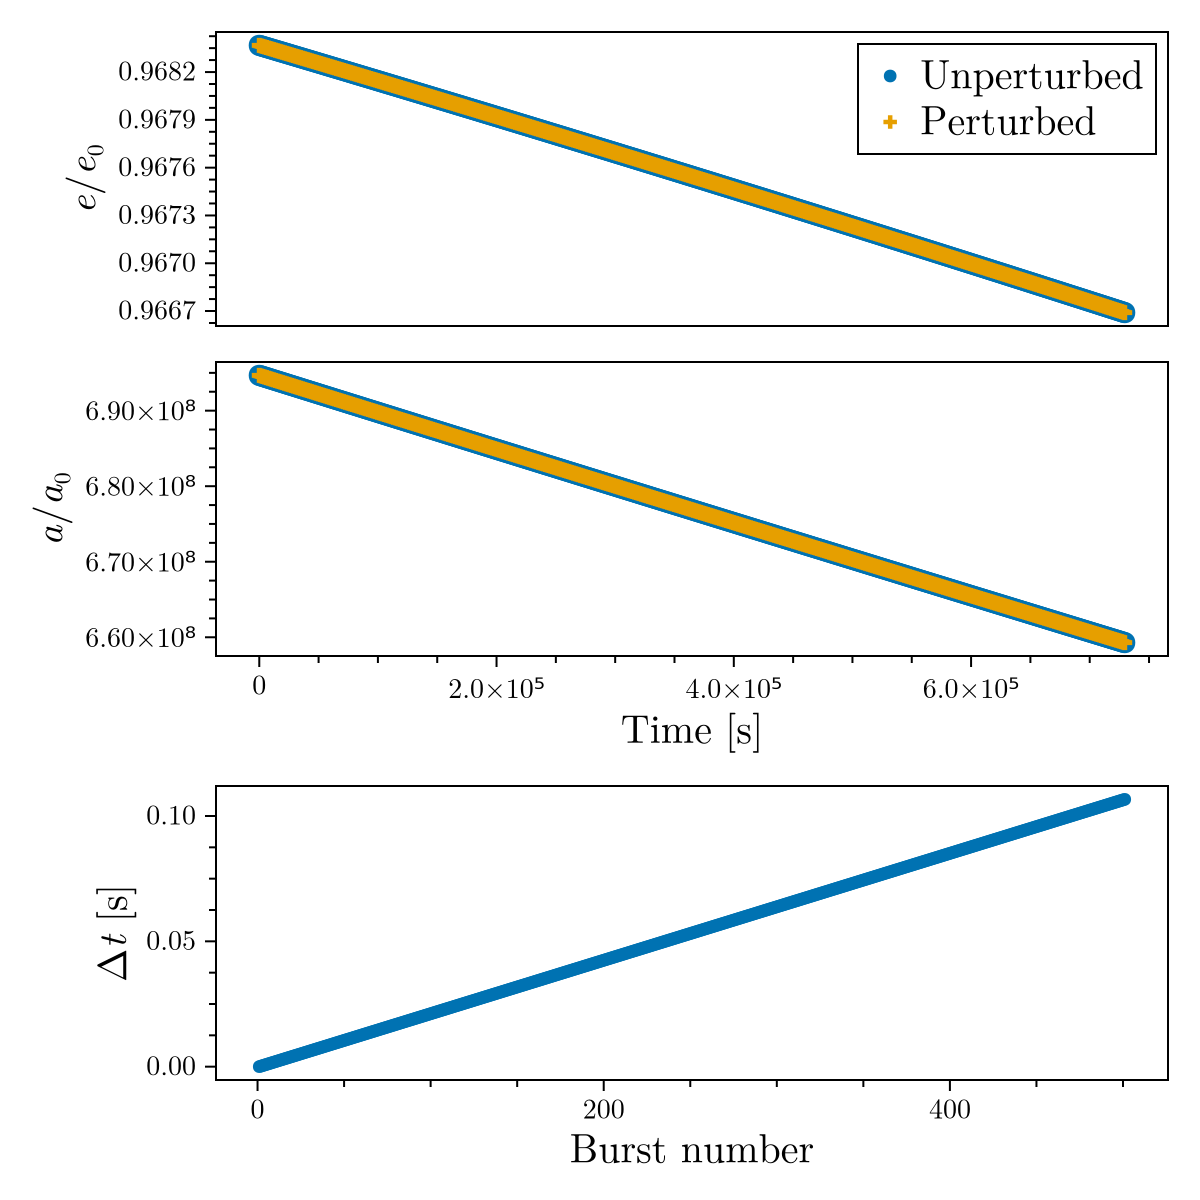

In [9]:
let filename = "../data/triple_bhbs/triple_properties_of_merging_systems.csv"
    df = CSV.File(filename)
    row_number = 1

    N = 500

    row = df[row_number, :][1]

    a0 = row.a_in
    m1, m2 = row.m1, row.m2
    m12 = m1 + m2
    eta = (m1*m2)/m12/m12
    i0 = row.i_mut
    e0 = row.e_in
    
    R3 = row.a_out
    m3 = row.m3
    e3 = row.e_out
    
    # free(?) params
    w0 = 0.0
    W0 = 0.0
    w3 = 0.0
    W3 = 0.0
    V3 = 1.2

    params = Dict(:a0 => a0, :e0 => e0, :m12 => m12, :i0 => i0, :w0 => w0, :W0 => W0,
                    :w3 => w3, :e3 => e3, :R3 => R3, :m3 => m3, :V3 => V3, :eta => eta)

    m, m_p = get_models(;params...)#do_evolution(N; all_params...)

    # EBT.evolve_to_fGW!(m, 0.01, max_bursts=100_000)
    # EBT.evolve_to_fGW!(m_p, 0.5, max_bursts=100_000)
    # m = let
    #     params = copy(params)
    #     params[:m3] = 0.0
    #     params[:a0] = get_a(m_p, 1)/EBT.Constants.Rsun_to_m
    #     params[:e0] = get_e(m_p, 1)
    #     params[:t0] = get_t(m_p, 1)
    #     get_unperturbed_model(;params...)
    # end


    evolve!(m, N)
    evolve!(m_p, N)

    e = get_e_array(m, N)
    a = get_a_array(m, N) 
    t = get_t_array(m, N)

    e_p = get_e_array(m_p, N)
    a_p = get_a_array(m_p, N) 
    t_p = get_t_array(m_p, N)

    fig = Figure(size=(600, 600))
    cs = Makie.wong_colors()

    ax_e = Axis(fig[1, 1], ylabel=L"e/e_0", yticks=LinearTicks(7))
    ax_p = Axis(fig[2, 1], xlabel="Time [s]", ylabel=L"a/a_0")
    ax_t = Axis(fig[3, 1], xlabel="Burst number", ylabel=L"$\Delta t$ [s]")

    hidexdecorations!(ax_e)
    linkxaxes!(ax_e, ax_p)

    # time_shift = line_up_burst_times(t_p, t)
    # t .+= time_shift
    # @show time_shift

    sc = scatter!(ax_e, t, e, color=cs[1], markersize=15)
    sc2 = scatter!(ax_p, t, a, color=cs[1], markersize=15)

    sc = scatter!(ax_e, t_p, e_p, color=cs[2], markersize=10, marker=:+)
    sc2 = scatter!(ax_p, t_p, a_p, color=cs[2], markersize=10, marker=:+)

    scatter!(ax_t, abs.(t .- t_p))
    # scatter!(ax_e, t_p)

    axislegend(ax_e, [MarkerElement(color=cs[1], marker=:circle), MarkerElement(color=cs[2], marker=:+)], 
                     ["Unperturbed", "Perturbed"], position=:rt, labelsize=20, framevisible=true)
    # Makie.save(joinpath(@__DIR__, "..", "figures", "example_system.png"), fig)
    fig
end

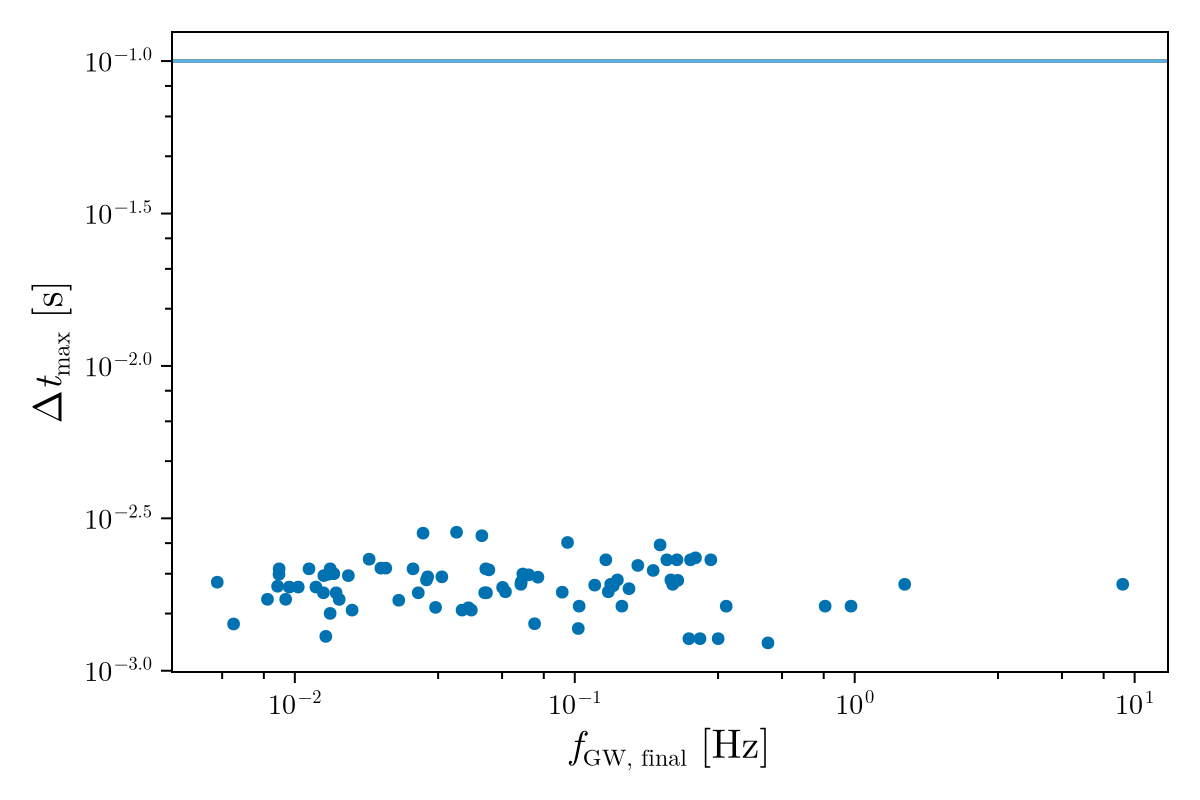

In [27]:
let filename = "../data/triple_bhbs/triple_properties_of_merging_systems.csv"
    df = CSV.File(filename)

    fig = Figure(size=(600, 400))
    ax = Axis(fig[1, 1], yscale=log10, ylabel=L"$\Delta t_\text{max}$ [s]", xlabel=L"$f_\text{GW, final}$ [Hz]", xscale=log10)

    N_bursts = 10

    N = 100
    i = 1
    while i < N && i < size(df, 1)
        # println(i)
        row = df[i,:][1]

        e0 = row.e_in

        if e0 < 0.7
            i += 1
            continue
        end

        a0 = row.a_in
        m1, m2 = row.m1, row.m2
        m12 = m1 + m2
        eta = (m1*m2)/m12/m12
        i0 = row.i_mut
        
        R3 = row.a_out
        m3 = row.m3
        e3 = row.e_out

        # println(a0, " ", R3, " ", m1, " ", m2, " ", m3)
        
        # free(?) params
        w0 = 0.0
        W0 = 0.0
        w3 = 0.0
        W3 = 0.0
        V3 = 0.0

        params = Dict(:a0 => a0, :e0 => e0, :m12 => m12, :i0 => i0, :w0 => w0, :W0 => W0,
                      :w3 => w3, :e3 => e3, :R3 => R3, :m3 => m3, :V3 => V3, :eta => eta)
    
        m, m_p = get_models(;params...)

        # try
        #     EBT.evolve_to_fGW!(m_p, 0.1, max_bursts=100_000)
        # catch err
        #     println(m_p)
        #     continue
        # end

        # m = let
        #     bin_params = copy(params)
        #     bin_params[:m3] = 0.0
        #     bin_params[:a0] = get_a(m_p, 1)/EBT.Constants.Rsun_to_m
        #     bin_params[:e0] = get_e(m_p, 1)
        #     bin_params[:t0] = get_t(m_p, 1)
        #     get_unperturbed_model(;bin_params...)
        # end

        evolve!(m, N_bursts)
        evolve!(m_p, N_bursts)

        # e = get_e_array(m, N)
        # a = get_a_array(m, N_bursts)
        # isempty(a) && continue
        # a = a[end]
        t = get_t_array(m, N)

        # e_p = get_e_array(m_p, N)
        # a_p = get_a_array(m_p, N_bursts)[end] 
        t_p = get_t_array(m_p, N)

        fgw = EBT.peak_f_GW(m, length(m.t))
        # time_shift = line_up_burst_times(t_p, t)

        scatter!(ax, fgw, maximum(i -> abs(t[i] - t_p[i]), eachindex(t)), color=Makie.wong_colors()[1])
        hlines!(ax, 1e-1)
        i += 1
    end
    fig
end

Do a check for how low we can push the modl in terms of eccentricity?
Evolve the systems from start to the end, and save the evolution